In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

import sys
from pathlib import Path

# sys.path.insert(0, str(Path.cwd() / "src"))

from model_alignment_lab.utils.helpers import generate_response, format_example
from model_alignment_lab.evaluation.eval import log_parser, evaluate_tutor_schema_df

from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
## Path Setup
root = Path.cwd()
output_dir = root.parent/"outputs"
datasets_dir = root.parent/"datasets"/"structured_json"
root

PosixPath('/home/derrjohn/git/model-alignment-lab/notebooks')

In [3]:
print(root.is_dir())
print(output_dir.is_dir())
print(datasets_dir.is_dir())

True
True
True


# 1. Base Model Preparation

In [4]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [51]:
prompt = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
An infinitely long conducting cylinder carries a time-varying current I(t). A circular conducting loop is placed nearby. Determine which electromagnetic laws and concepts are required to derive the induced voltage in the loop, and explain the most common mistakes students make when solving this type of problem."""

response = generate_response(model, tokenizer, prompt)
print(response)

{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "cylindrical symmetry", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate voltage", "solve induction time"], "common_mistakes": ["incorrectly integrate or sum fields", "missing time lag"], "prerequisites": ["integration", "vector calculus"]}


In [6]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=30,
    benchmark=True
)
# print(result["text"])
# print()
print(f"Total Time: {np.round(result['total_time_s'],2)}")
print(f"Generated Tokens: {np.round(result['generated_tokens'],2)}")
print(f"Tokens per second: {np.round(result['tokens_per_second'],2)}")

Total Time: 0.61
Generated Tokens: 30
Tokens per second: 49.34


In [7]:
train_path = datasets_dir.joinpath("TRAIN_em_tutor_chat.jsonl")
test_path = datasets_dir.joinpath("VAL_em_tutor_chat.jsonl")
val_path = datasets_dir.joinpath("TEST_em_tutor_chat.jsonl")

In [8]:
print(train_path.is_file())
print(test_path.is_file())
print(val_path.is_file())

True
True
True


In [9]:


train_dataset = load_dataset("json",
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

In [10]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 500
})

In [11]:
train_dataset["messages"][0]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.'},
 {'role': 'assistant',
  'content': '{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}'}]

In [12]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

In [13]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 500
})

In [14]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.<|im_end|>
<|im_start|>assistant
{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}<|im_end|>



# 2. LoRA Finetune 

### LoRA Setup

In [15]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","v_proj"] # target_modules=["q_proj","k_proj","v_proj","o_proj"]
    
)


In [16]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [17]:
model.print_trainable_parameters()

trainable params: 819,200 || all params: 362,640,320 || trainable%: 0.2259


## Training

In [18]:
training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-em-tutor-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [19]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.544928,0.505091
2,0.100476,0.087835
3,0.056017,0.057136


TrainOutput(global_step=375, training_loss=0.5968983284632365, metrics={'train_runtime': 236.2794, 'train_samples_per_second': 6.348, 'train_steps_per_second': 1.587, 'total_flos': 495205364390400.0, 'train_loss': 0.5968983284632365})

In [21]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [22]:
final_path = str(output_dir/"smollm-em-tutor-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")

('/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_224753_final_adapter_v1/tokenizer_config.json',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_224753_final_adapter_v1/chat_template.jinja',
 '/home/derrjohn/git/model-alignment-lab/outputs/smollm-em-tutor-lora/20260512_224753_final_adapter_v1/tokenizer.json')

## Model Evaluation

In [23]:
trainer.state.log_history

[{'loss': 3.009235954284668,
  'grad_norm': 0.4098290801048279,
  'learning_rate': 0.00019786666666666666,
  'entropy': 1.9761421263217926,
  'num_tokens': 3430.0,
  'mean_token_accuracy': 0.48899191468954084,
  'epoch': 0.04,
  'step': 5},
 {'loss': 2.808688163757324,
  'grad_norm': 0.4466160833835602,
  'learning_rate': 0.0001952,
  'entropy': 1.984260493516922,
  'num_tokens': 6940.0,
  'mean_token_accuracy': 0.5063998401165009,
  'epoch': 0.08,
  'step': 10},
 {'loss': 2.676080513000488,
  'grad_norm': 0.45097264647483826,
  'learning_rate': 0.00019253333333333334,
  'entropy': 2.0379231452941893,
  'num_tokens': 10403.0,
  'mean_token_accuracy': 0.5219873547554016,
  'epoch': 0.12,
  'step': 15},
 {'loss': 2.617975616455078,
  'grad_norm': 0.4534148871898651,
  'learning_rate': 0.00018986666666666668,
  'entropy': 2.097904163599014,
  'num_tokens': 13870.0,
  'mean_token_accuracy': 0.5259054228663445,
  'epoch': 0.16,
  'step': 20},
 {'loss': 2.4743669509887694,
  'grad_norm': 0.4

In [24]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12, 1.16, 1.2, 1.24, 1.28, 1.32, 1.3599999999999999, 1.4, 1.44, 1.48, 1.52, 1.56, 1.6, 1.6400000000000001, 1.6800000000000002, 1.72, 1.76, 1.8, 1.8399999999999999, 1.88, 1.92, 1.96, 2.0, 2.04, 2.08, 2.12, 2.16, 2.2, 2.24, 2.2800000000000002, 2.32, 2.36, 2.4, 2.44, 2.48, 2.52, 2.56, 2.6, 2.64, 2.68, 2.7199999999999998, 2.76, 2.8, 2.84, 2.88, 2.92, 2.96, 3.0]
[3.009235954284668, 2.808688163757324, 2.676080513000488, 2.617975616455078, 2.4743669509887694, 2.3254356384277344, 2.209971046447754, 2.040956497192383, 1.9133502960205078, 1.759040069580078, 1.5552916526794434, 1.4010969161987306, 1.2185790061950683, 1.1252069473266602, 1.0237602233886718, 0.8831645965576171, 0.8378745079040527, 0.750986909866333, 0.7426969528198242, 0.6965705394744873, 0.6474937438964844, 0.654175853729248, 0.616279125213623, 0.5851382732391357, 0.5449279

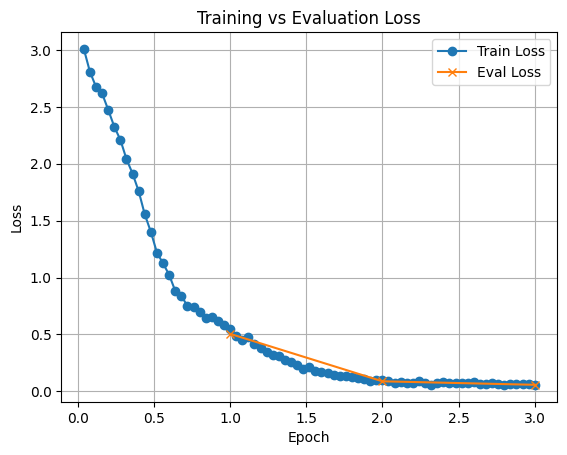

In [25]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [26]:
prompt

'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.'

In [27]:
response = generate_response(model, tokenizer, prompt)
print(response)

{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}


In [28]:
print(test_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Identify common conceptual pitfalls.<|im_end|>
<|im_start|>assistant
{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}<|im_end|>



In [29]:
df = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df.head()

,prompt,valid_json,pred_problem_type,actual_problem_type,problem_type_match,pred_difficulty,actual_difficulty,difficulty_match,pred_required_concepts,actual_required_concepts,...,equations_match,pred_final_answer,actual_final_answer,final_answer_match,pred_common_mistakes,actual_common_mistakes,mistakes_match,overall_match,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
1,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
2,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."
3,Return ONLY valid JSON.\n\nYou are a helpful p...,True,student_support,student_support,True,beginner,beginner,True,"[wave propagation, time varying fields]","[wave propagation, time varying fields]",...,True,None,None,True,"[assuming instantaneous propagation, confusing...","[assuming instantaneous propagation, confusing...",True,True,"{""problem_type"": ""student_support"", ""difficult...","{""problem_type"": ""student_support"", ""difficult..."
4,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."


In [32]:
[col for col in df.columns.tolist() if "match" in col]

['problem_type_match',
 'difficulty_match',
 'concepts_match',
 'strategy_match',
 'equations_match',
 'final_answer_match',
 'mistakes_match',
 'overall_match']

In [33]:
df[[col for col in df.columns.tolist() if "match" in col]].value_counts()

problem_type_match  difficulty_match  concepts_match  strategy_match  equations_match  final_answer_match  mistakes_match  overall_match
True                True              True            True            True             True                True            True             100
Name: count, dtype: int64

In [34]:
df.problem_type_match.value_counts()

problem_type_match
True    100
Name: count, dtype: int64

In [35]:
df.difficulty_match.value_counts()

difficulty_match
True    100
Name: count, dtype: int64

In [36]:
df.final_answer_match.value_counts()

final_answer_match
True    100
Name: count, dtype: int64

## Train mas

In [ ]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

## Model v2 Eval

In [ ]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

In [ ]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [ ]:
prompt 

In [ ]:
generate_response(model, tokenizer, prompt)

In [ ]:
df_2 = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df_2.head()

In [ ]:
df_2.problem_type_match.value_counts()

In [ ]:
df_2.difficulty_match.value_counts()

In [ ]:
df_2.final_answer_match.value_counts()

In [ ]:
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")

In [ ]:
prompt_2 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
Which problems do I find most difficult?"""


In [ ]:
generate_response(model, tokenizer, prompt_2)

In [ ]:
structured_output = generate_response(model, tokenizer, prompt_2)
print(structured_output)

In [37]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)
print(base_model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [ ]:
prompt_final = f"""
You are a helpful electromagnetics tutor.

Given the structured analysis below, explain the problem
to a student in a natural educational way.

Structured analysis:
{structured_output}

Tutor explanation:
"""
response = generate_response(base_model, tokenizer, prompt_final, max_new_tokens=500)
print(response)

In [ ]:
model

### Reduce Rank

In [40]:
peft_config = LoraConfig(
    r=2,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","v_proj"],
    use_dora=True
)


In [41]:
model = get_peft_model(base_model, peft_config).to(base_model.device)
model.train()

/home/derrjohn/git/model-alignment-lab/.venv/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/derrjohn/git/model-alignment-lab/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=2, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=2, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict(
                  (default): lora.dora.DoraLi

In [42]:
model.print_trainable_parameters()

trainable params: 491,520 || all params: 362,312,640 || trainable%: 0.1357


## Training

In [43]:
training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-em-tutor-lora-r4"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [44]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

In [45]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.213300,0.179591
2,0.038791,0.038947
3,0.032867,0.031819


TrainOutput(global_step=375, training_loss=0.4088268092473348, metrics={'train_runtime': 473.1502, 'train_samples_per_second': 3.17, 'train_steps_per_second': 0.793, 'total_flos': 494690967083520.0, 'train_loss': 0.4088268092473348})

In [46]:
trainer.state.log_history

[{'loss': 2.9747137069702148,
  'grad_norm': 0.9085246324539185,
  'learning_rate': 0.00019786666666666666,
  'entropy': 1.984375,
  'num_tokens': 3430.0,
  'mean_token_accuracy': 0.49550487101078033,
  'epoch': 0.04,
  'step': 5},
 {'loss': 2.6976842880249023,
  'grad_norm': 0.8556059002876282,
  'learning_rate': 0.0001952,
  'entropy': 2.008984375,
  'num_tokens': 6940.0,
  'mean_token_accuracy': 0.5120292395353317,
  'epoch': 0.08,
  'step': 10},
 {'loss': 2.492671585083008,
  'grad_norm': 0.8707992434501648,
  'learning_rate': 0.00019253333333333334,
  'entropy': 2.088671875,
  'num_tokens': 10403.0,
  'mean_token_accuracy': 0.5454439908266068,
  'epoch': 0.12,
  'step': 15},
 {'loss': 2.3724748611450197,
  'grad_norm': 0.9100364446640015,
  'learning_rate': 0.00018986666666666668,
  'entropy': 2.16015625,
  'num_tokens': 13870.0,
  'mean_token_accuracy': 0.5655333220958709,
  'epoch': 0.16,
  'step': 20},
 {'loss': 2.165134048461914,
  'grad_norm': 0.9768749475479126,
  'learning_

In [47]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

print(train_epochs)
print(train_losses)
print(eval_epochs)
print(eval_losses)

[0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12, 1.16, 1.2, 1.24, 1.28, 1.32, 1.3599999999999999, 1.4, 1.44, 1.48, 1.52, 1.56, 1.6, 1.6400000000000001, 1.6800000000000002, 1.72, 1.76, 1.8, 1.8399999999999999, 1.88, 1.92, 1.96, 2.0, 2.04, 2.08, 2.12, 2.16, 2.2, 2.24, 2.2800000000000002, 2.32, 2.36, 2.4, 2.44, 2.48, 2.52, 2.56, 2.6, 2.64, 2.68, 2.7199999999999998, 2.76, 2.8, 2.84, 2.88, 2.92, 2.96, 3.0]
[2.9747137069702148, 2.6976842880249023, 2.492671585083008, 2.3724748611450197, 2.165134048461914, 1.9399633407592773, 1.7506793975830077, 1.499545192718506, 1.3315258026123047, 1.135733413696289, 0.9145011901855469, 0.7992332458496094, 0.6991614818572998, 0.6886931419372558, 0.6590850353240967, 0.5735363483428955, 0.5581218719482421, 0.4687000274658203, 0.4504733085632324, 0.39281883239746096, 0.32931902408599856, 0.3340315818786621, 0.29501211643218994, 0.23478472232818604,

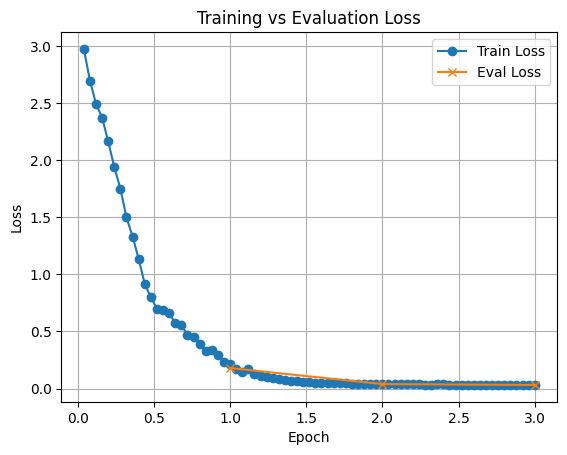

In [48]:
figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [49]:
prompt

'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.'

In [50]:
response = generate_response(model, tokenizer, prompt)
print(response)

{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}


In [ ]:
print(test_dataset["text"][0])

In [ ]:
df = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df.head()

In [ ]:
df.problem_type_match.value_counts()

In [ ]:
df.difficulty_match.value_counts()

In [ ]:
df.final_answer_match.value_counts()

In [ ]:
df.equations_match.value_counts()

In [ ]:
df.columns.tolist()

In [ ]:
df.overall_match.value_counts()

In [ ]:
df.concepts_match.value_counts()

In [ ]:
df.equations_match.value_counts()

In [ ]:
df.pred_final_answer.value_counts()

In [ ]:
df.shape

In [ ]:
prompt_3 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A uniformly charged sphere has radius R and charge density ρ. Find the electric field inside and outside the sphere."""

generate_response(model, tokenizer, prompt_3)

In [ ]:
prompt_4 = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields."""

structured_output = generate_response(model, tokenizer, prompt_4)

In [ ]:
prompt_final = f"""
You are a helpful electromagnetics tutor.

Given the structured analysis below, explain the problem
to a student in a natural educational way.

Structured analysis:
{structured_output}

Tutor explanation:
"""
response = generate_response(base_model, tokenizer, prompt_final, max_new_tokens=500)
print(response)